# Dependecies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare the Dataset

In [306]:
df = pd.read_csv('/kaggle/input/datasets/amar5693/student-performance-dataset/ultimate_student_productivity_dataset_5000.csv')
df.drop('student_id', axis=1, inplace=True)
df.head(2)

,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,18,Other,High School,7.64,1.56,2.2,3.05,2.19,6.52,6.47,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,18,Other,High School,2.21,2.22,2.1,1.65,2.55,5.97,6.05,111,339,0,0,Good,3,15.92,37.00,13.70,1.00


In [307]:
target_col = "productivity_score"

categorical_cols = ["gender", "academic_level", "internet_quality"]
binary_cols = ["part_time_job", "upcoming_deadline"]

numeric_cols = [
    "age", "study_hours", "self_study_hours", "online_classes_hours",
    "social_media_hours", "gaming_hours", "sleep_hours",
    "screen_time_hours", "exercise_minutes", "caffeine_intake_mg",
    "mental_health_score", "focus_index", "burnout_level", "exam_score"
]

In [308]:
# 3. Ordinal Encoding
academic_map = {'High School': 0, 'Undergraduate': 1, 'Postgraduate': 2}
internet_map = {'Poor': 0, 'Average': 1, 'Good': 2}
df['academic_level'] = df['academic_level'].map(academic_map)
df['internet_quality'] = df['internet_quality'].map(internet_map)

# Use this for Linear Regression
df = pd.get_dummies(df, columns=['gender'], prefix='gender', dtype=int, drop_first=True)
# df = pd.get_dummies(df, columns=["gender","academic_level","internet_quality"], drop_first=True)

In [309]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 4000 samples
Testing set: 1000 samples


In [310]:
scaler = StandardScaler()

# Fit ONLY on training numeric columns
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform test numeric columns using train statistics
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [311]:
X_train_array = X_train.to_numpy()
y_train_array = y_train.to_numpy().reshape(-1, 1)

X_test_array = X_test.to_numpy()
y_test_array = y_test.to_numpy().reshape(-1, 1)


print("shape of X train: ",X_train_array.shape)
print('Shape of y train: ',y_train_array.shape)

print("shape of X test: ",X_test_array.shape)
print('Shape of y test: ',y_test_array.shape)

shape of X train:  (4000, 20)
Shape of y train:  (4000, 1)
shape of X test:  (1000, 20)
Shape of y test:  (1000, 1)


# LR


In [312]:
# MSE
def cost_mse(y_array, y_pred):
    N = y_array.shape[0]
    return np.sum((y_pred - y_array)**2) / (2*N)
    
def gradient_computation(X_array,y_pred, y_array):
    N = X_array.shape[0]
    dw = (1/N) * X_array.T @(y_pred - y_array)
    db = (1/N) * np.sum(y_pred - y_array)
    return dw,db

def gradient_descent(w, b, dw, db, learning_rate):
    w = w - learning_rate * dw
    b = b - learning_rate * db
    return w,b

def LinearRegression(X_array,y_array,learning_rate,n_epoch):
    w = np.zeros((X_array.shape[1],1))
    b = 0.0
    J = np.zeros(n_epoch)
    
    for i in range(n_epoch):
        y_pred = X_array @ w + b
        J[i] = cost_mse(y_array,y_pred)
        dw, db = gradient_computation(X_array, y_pred, y_array)
        w, b  = gradient_descent(w, b, dw, db, learning_rate)
        
    y_pred = X_array @ w + b
    return J,y_pred,w, b

In [313]:
learning_rate = 1e-1
n_epoch = 5000
J,y_train_pred,w,b = LinearRegression(X_train_array,y_train_array,learning_rate,n_epoch)

# Validation

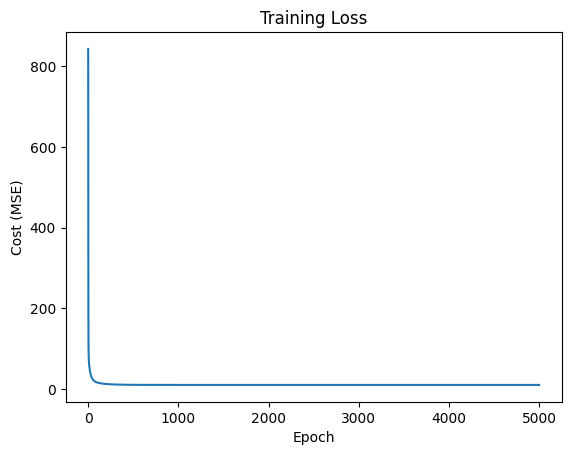

In [314]:
plt.plot(J)
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.title("Training Loss")
plt.show()

In [315]:
train_cost = cost_mse(y_train_array, y_train_pred)
print('Final Train Cost RMSE: ', np.sqrt(train_cost))

Final Train Cost RMSE:  3.1627153424087253


In [316]:
y_test_pred = X_test_array @ w + b
test_cost = cost_mse(y_test_array, y_test_pred)
print('Final Test Cost RMSE: ', np.sqrt(test_cost))

Final Test Cost RMSE:  3.215814260335316
